# Testing LOSD
### Bevölkerung nach Konfession, seit 1934

Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Religion und Jahr, seit 1934.

- LOSD: https://data.integ.stadt-zuerich.ch/dataset/bev316od3160
- INT: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_konfession_od3160
- PROD: https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_konfession_od3160

Datum: 15.03.2024




### Importiere die notwendigen Packages

In [68]:
#%pip install altair datetime folium geopandas io requests matplotlib numpy pandas seaborn plotly
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())


6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)


In [69]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotly.express as px
import requests
import seaborn as sns

In [70]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [71]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [72]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [73]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln

In [74]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

**BITTE HIER ANPASSEN**

In [75]:
#speichere die variable global, damit ich sie später verwenden kann, wenn ich grafiken mit diesem namen speichere.
losd_package_name = "bev316od3160"
package_name = "bev_bestand_jahr_konfession_od3160"

In [76]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV316OD3160"    
    , datums_attr = ['StichtagDatJahr']
    )


fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_konfession_od3160/download/BEV316OD3160.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_konfession_od3160 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_bestand_jahr_konfession_od3160 

data_source: web


In [77]:
data2betested.head(2)

,StichtagDatJahr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir
0,1934-01-01,3,3,"Andere, ohne, unbekannt",14767
1,1934-01-01,1,1,Evangelisch-Reformiert,208357


Berechne weitere Attribute falls notwendig

-------------------------------------------------------

In [78]:
data2betested = (
    data2betested
    .copy()
    .assign(

        ZEIT_LANG = lambda x: x.StichtagDatJahr,
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
        BEW = lambda x: x.AnzBestWir.astype(int),

        #StichtagDatJahr = lambda x: x.ZEIT_LANG.apply(convert_to_datetime),
        #StichtagDatJahr_str = lambda x: x.ZEIT_LANG.astype(str),
        #Jahr_nbr = lambda x: x.ZEIT_CODE.str[-4:].astype(int),    
        #RAUM_my_sort = lambda x: x.ZEIT_CODE.str[1:].astype(int),

    )
    .sort_values('ZEIT_LANG', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr     datetime64[ns]
Kon2AggSort_noDM             int64
Kon2AggCd_noDM               int64
Kon2AggLang_noDM            object
AnzBestWir                   int64
ZEIT_LANG           datetime64[ns]
Jahr                datetime64[ns]
Jahr_end            datetime64[ns]
Jahr_nbr                     int32
BEW                          int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [79]:
data_max_date = str(max(data2betested.StichtagDatJahr).year)
data_min_date = str(min(data2betested.StichtagDatJahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1934 und ein Maximumjahr von 2024


Zeitbereich aus den Daten:

In [80]:
data_max_date = str(max(data2betested.Jahr_nbr))

try:
    if min(data2betested.Jahr_nbr) < 1678:
        data_min_date="1688"
    else:
        data_min_date = str(min(data2betested.Jahr_nbr))
except ValueError:
    print("Fehler...")

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")


Die Daten haben ein Minimumjahr von 1934 und ein Maximumjahr von 2024


### Einfache Datentests

In [81]:
data2betested.head(2).T

,272,271
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
Kon2AggSort_noDM,3,1
Kon2AggCd_noDM,3,1
Kon2AggLang_noDM,"Andere, ohne, unbekannt",Evangelisch-Reformiert
AnzBestWir,283629,71413
ZEIT_LANG,2024-01-01 00:00:00,2024-01-01 00:00:00
Jahr,2024-01-01 00:00:00,2024-01-01 00:00:00
Jahr_end,2024-12-31 00:00:00,2024-12-31 00:00:00
Jahr_nbr,2024,2024
BEW,283629,71413


In [82]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 272 to 0
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   StichtagDatJahr   273 non-null    datetime64[ns]
 1   Kon2AggSort_noDM  273 non-null    int64         
 2   Kon2AggCd_noDM    273 non-null    int64         
 3   Kon2AggLang_noDM  273 non-null    object        
 4   AnzBestWir        273 non-null    int64         
 5   ZEIT_LANG         273 non-null    datetime64[ns]
 6   Jahr              273 non-null    datetime64[ns]
 7   Jahr_end          273 non-null    datetime64[ns]
 8   Jahr_nbr          273 non-null    int32         
 9   BEW               273 non-null    int32         
dtypes: datetime64[ns](4), int32(2), int64(3), object(1)
memory usage: 42.1 KB


In [83]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 273 rows (observations) and 10 columns (variables).
There seem to be 0 exact duplicates in the data.


Welches sind die Quartiere ohne Werte bei BEW?

In [84]:
data2betested[np.isnan(data2betested.BEW)]

,StichtagDatJahr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [85]:
data2betested = data2betested.set_index("StichtagDatJahr") 
data2betested = data2betested.sort_index()

In [86]:
data2betested.index.year.unique()


Index([1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948,
       1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963,
       1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978,
       1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [87]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [88]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,Kon2AggSort_noDM,Kon2AggCd_noDM,AnzBestWir,Jahr_nbr,BEW
count,273,273,273,273,273
mean,2,2,"128,716","1,979","128,716"
std,1,1,"71,735",26,"71,735"
min,1,1,"13,634","1,934","13,634"
25%,1,1,"90,793","1,956","90,793"
50%,2,2,"123,217","1,979","123,217"
75%,3,3,"163,934","2,002","163,934"
max,3,3,"283,629","2,024","283,629"


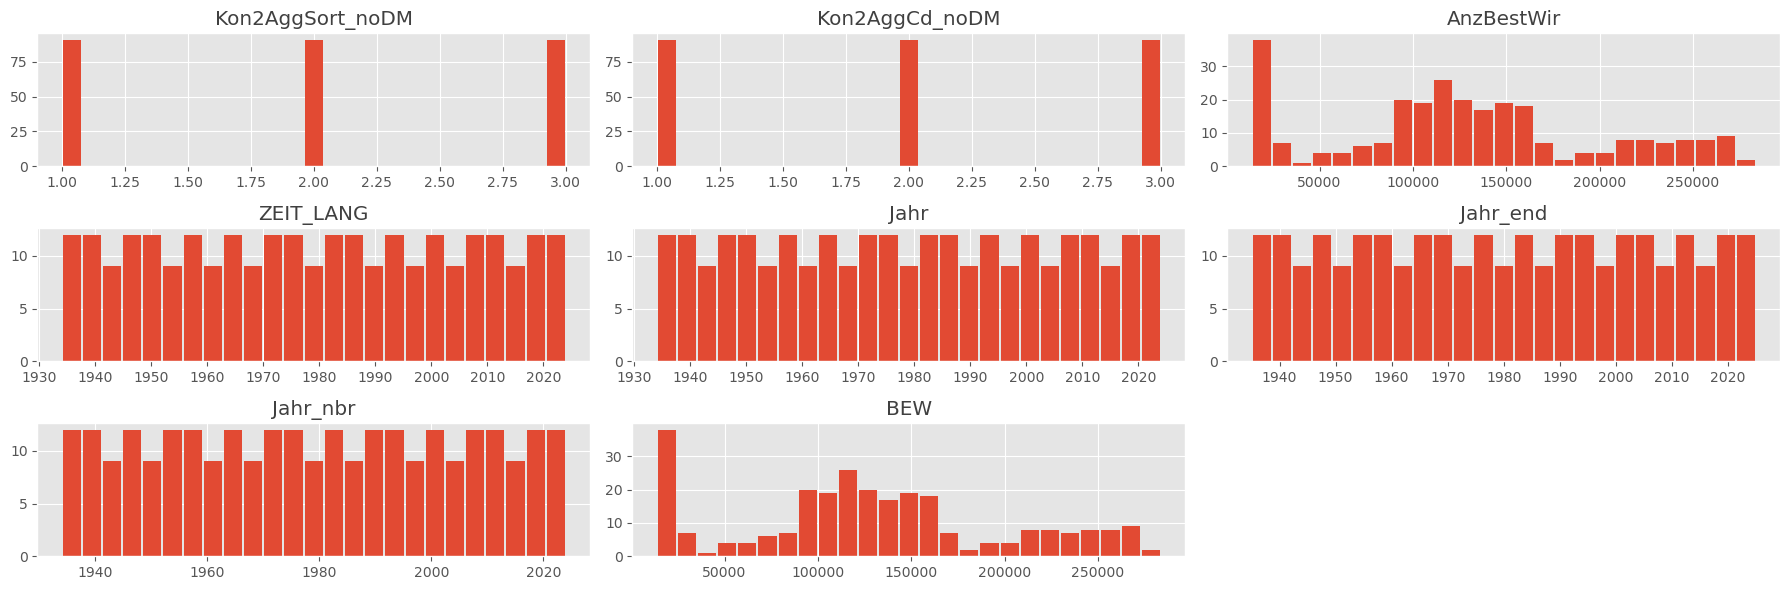

In [89]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [90]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW
StichtagDatJahr,,,,,,,,,


### Nullwerte und Missings?

In [91]:
data2betested.isnull().sum()

Kon2AggSort_noDM    0
Kon2AggCd_noDM      0
Kon2AggLang_noDM    0
AnzBestWir          0
ZEIT_LANG           0
Jahr                0
Jahr_end            0
Jahr_nbr            0
BEW                 0
dtype: int64

In [92]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [93]:
data2betested.columns

Index(['Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'AnzBestWir', 'ZEIT_LANG', 'Jahr',
       'Jahr_end', 'Jahr_nbr', 'BEW'],
      dtype='object')

In [94]:
agg_Rel = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr','Jahr_nbr', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM']) \
    .agg(sum_AnzBestWir=('BEW', 'sum')) \
    .sort_values(['Jahr_nbr','Kon2AggSort_noDM'], ascending=[False, True]) 
agg_Rel.reset_index().head(5)

,Jahr,Jahr_nbr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,sum_AnzBestWir
0,2024-01-01,2024,1,1,Evangelisch-Reformiert,71413
1,2024-01-01,2024,2,2,Römisch-Katholisch,93622
2,2024-01-01,2024,3,3,"Andere, ohne, unbekannt",283629
3,2023-01-01,2023,1,1,Evangelisch-Reformiert,74269
4,2023-01-01,2023,2,2,Römisch-Katholisch,97639


### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [95]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW
StichtagDatJahr,,,,,,,,,
2024-01-01,2,2,Römisch-Katholisch,93622,2024-01-01,2024-01-01,2024-12-31,2024,93622
2024-01-01,1,1,Evangelisch-Reformiert,71413,2024-01-01,2024-01-01,2024-12-31,2024,71413


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wohnbevölkerung seit ...

In [96]:
myAgg1 = agg_Rel

myAgg1.reset_index().head(1)

,Jahr,Jahr_nbr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,sum_AnzBestWir
0,2024-01-01,2024,1,1,Evangelisch-Reformiert,71413


In [99]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('sum_AnzBestWir>3')
    , x = 'Jahr:T'
    , y = 'sum_AnzBestWir:Q'
    , x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    , warning_status  = "ignore"
    , category='Kon2AggLang_noDM'
    , category_beschriftung='legende:'
    , myTitle="Bevölkerungsentwicklung nach Konfession, seit "+data_min_date    
)
grafik1

alt.LayerChart(...)

## ---------------------- hier Plausi beendet

- Sharepoint SASA: [Sharepoint](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=480&e=Io55R7)

- Übersicht zu LOSD-Jobs:
[Sharepoint](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/OGD%20Metadaten.aspx#InplviewHasheb69a2c0-ed94-4ef2-91a5-3b19f038e442=FilterField1%3DMetadaten%255Fx002d%255FPublikations%255Fx00-FilterValue1%3DINT)

--------------